# Getting started with Beamforming

® *Copyright Bimea 2024-2025*

In this Notebook, we propose to perform beamforming operation on signals comming from a simulated antenna using the `Beamformer` class. 

Dependencies: 
* `pip install pyroomacoustics`

## Generating a source in a free field acoustic environment

Free-field sound propagation between a set of sound sources and a set of microphones can be simulated using the *AnechoicRoom* class of the *Pyroomacoustics* library. It simply consists in setting the maximum image image order of the room simulation to zero:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from megamicros.log import log
from megamicros.core.base import MemsArray
from megamicros.geometry import circle
import pyroomacoustics as pra

log.setLevel( "INFO" ) 

MEMS_NUMBER = 32

# Create the antenna
antenna = MemsArray()
antenna.setAvailableMems( list(range(MEMS_NUMBER)) )
antenna.setSamplingFrequency(16000)

# Set MEMS positions: a circular array of radius 0.175 m
mems_position = np.array( circle( 
    points_number=MEMS_NUMBER, 
    radius=0.175, 
    height=0.0, 
    angle_offset=2 * np.pi / MEMS_NUMBER / 2, 
    clockwise=True ) )

                                             
# Create an anechoic room.
room = pra.AnechoicRoom(fs=16000)

# Attach the antenna to the room.
room.add_microphone_array(mems_position.T.tolist())

# Add a source. We use a white noise signal for the source, and
# the source can be arbitrarily far because there are no walls.
source = np.random.randn(1024)
source_position = [1, 0, -2]
room.add_source(source_position, signal=source)

# run the simulation
signal = room.simulate(return_premix=True)[0,:].T


source.shape:  (1024,)
signal.shape (1214, 32)


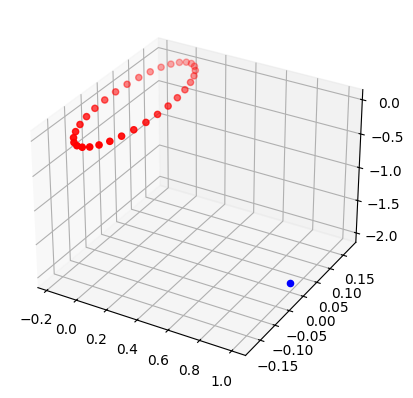

In [17]:
print("source.shape: ", source.shape)
print("signal.shape", signal.shape)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(mems_position.T[0,:], mems_position.T[1,:], mems_position.T[2,:], c='r', marker='o')
ax.scatter(source_position[0], source_position[1], source_position[2], c='b', marker='o')


## Init the Beamformer

In [18]:
from megamicros.acoustics.bmf import BeamformerFDAS
from megamicros.geometry import horizontalPlan

# Define antenna focal
focal_plan_width = 4.0
focal_plan_depth = 4.0
focal_depth = 2.0
focal_plan_width_sampling = 41
focal_plan_depth_sampling = 41

locations = np.array( horizontalPlan( focal_plan_width, focal_plan_depth, focal_depth, focal_plan_width_sampling, focal_plan_depth_sampling ) )

# Create the beamformer
bmf = BeamformerFDAS( 
    mems_position = mems_position,
    locations = locations,
    sampling_frequency = antenna.sampling_frequency,
    frame_length = antenna.frame_length,
)

2025-11-06 13:42:59,440 [INFO]:  .Set beamformer on a 32 MEMs antenna
2025-11-06 13:42:59,441 [INFO]:  .Set beamformer sampling frequency to 16000 Hz
2025-11-06 13:42:59,442 [INFO]:  .Set 1681 beamforming locations
2025-11-06 13:42:59,442 [INFO]:  .Set beamformer frame length to 1024 Samples
2025-11-06 13:42:59,443 [INFO]:  .Set beamformer FFT window size to 1024 samples
2025-11-06 13:42:59,444 [INFO]:  .BeamformerFDAS Initilization:
2025-11-06 13:42:59,445 [INFO]:   > Found antenna with 32 MEMs microphones
2025-11-06 13:42:59,445 [INFO]:   > FFT window size is 1024 samples
2025-11-06 13:42:59,446 [INFO]:   > Time range: [0, 0.0639375] s
2025-11-06 13:42:59,446 [INFO]:   > Sampling frequency: 16000 Hz
2025-11-06 13:42:59,446 [INFO]:   > Frequency range: [0, 8000.0] Hz (513 beams)
2025-11-06 13:42:59,446 [INFO]:   > frequency step: 15.59 Hz
2025-11-06 13:42:59,447 [INFO]:   > frequency bandwidth: [0.00, 8000.00] Hz
2025-11-06 13:42:59,447 [INFO]:   > frequency bandwidth indexes: [0, 512

Compute the BFE

In [19]:
BFE, _, _ = bmf.compute( signal )
image = BFE.reshape( ( focal_plan_depth_sampling, focal_plan_width_sampling ) )

2025-11-06 13:43:04,393 [WARNING]: in megamicros.log (bmf.py:336):  .bmf > Input signal is longer than FFT width: it will be truncated


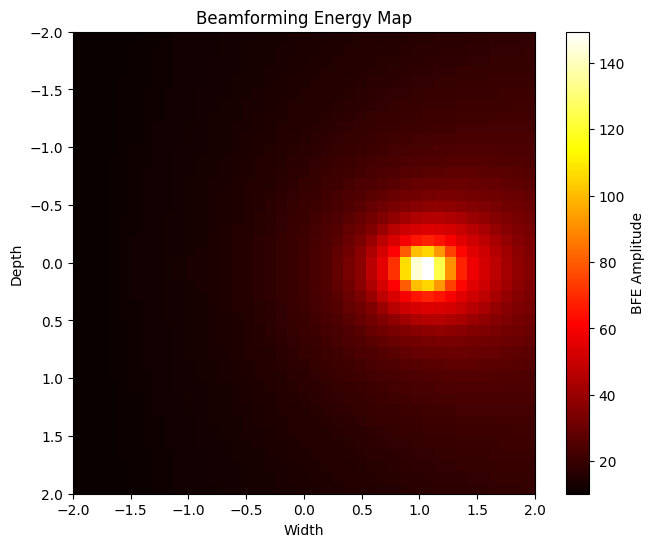

In [20]:
# Calculate the extent of the focal plane in meters
width_extent = [-focal_plan_width/2, focal_plan_width/2]
depth_extent = [-focal_plan_depth/2, focal_plan_depth/2]

# Display the beamforming energy map on the focal plane
plt.figure(figsize=(8, 6))
plt.imshow(
    image, cmap='hot', 
    interpolation='nearest', 
    extent=[width_extent[0], 
        width_extent[1], 
        depth_extent[1], 
        depth_extent[0]
    ]
)
plt.colorbar(label='BFE Amplitude')
plt.title('Beamforming Energy Map')
plt.xlabel('Width')
plt.ylabel('Depth')
plt.show()

In [21]:
# Store the 3D locations in a json file
import json

print("locations.shape: ", locations.shape)
with open("locations.json", "w") as f:
    json.dump(locations.tolist(), f)
#!/usr/bin/env python3

# Store 3D MEMS positions in a json file
with open("mems_positions.json", "w") as f:
    json.dump(mems_position.tolist(), f)


# Transform the signal into a 1D vector of values interleaved per MEMS
# (e.g., [mems1_sample1, mems2_sample1, ..., memsN_sample1, mems1_sample2, ...])
# and store it in a json file
# Flatten the signal array in C order (row-major) to achieve interleaving
signal_flat = signal.flatten(order='C')
print(signal_flat.shape)
print(signal_flat[:10])  # Print first 10 samples for verification

# Store the signal in a json file
with open("signal.json", "w") as f:
    json.dump(signal_flat.tolist(), f)


locations.shape:  (1681, 3)
(38848,)
[-1.12342433e-08 -1.77745410e-08 -1.56847372e-08  4.20444393e-08
 -4.98452078e-09  5.37079304e-08 -2.32124137e-08 -7.51953293e-09
 -7.51953293e-09 -2.32124137e-08]


In [22]:
print("locations.shape: ", locations.shape)
print("BFE.shape: ", BFE.shape)
print("image.shape: ", image.shape)

locations.shape:  (1681, 3)
BFE.shape:  (1681,)
image.shape:  (41, 41)


## Do the same with a 32 MEMS square antenna

Load absolute positiones of MEMS and transform them into positions relative to the center of the antenna

In [ ]:
with open("mems_position_square_absolute.json", "r") as f:
    mems_position_square_absolute = json.load(f)

print("mems_position_square_absolute.shape: ", np.array(mems_position_square_absolute).shape)
print("mems_position_square_absolute: ", mems_position_square_absolute)

antenna_center_position = [25.0, 27.0, 0.0]
mems_position_square_relative = np.array(mems_position_square_absolute) - np.array(antenna_center_position)
print("mems_position_square_relative.shape: ", mems_position_square_relative.shape)
print("mems_position_square_relative: ", mems_position_square_relative)

with open("mems_position_square_relative.json", "w") as f:
    json.dump(mems_position_square_relative.tolist(), f)

mems_position_square_absolute.shape:  (32, 3)
mems_position_square_absolute:  [[3.2, 46.7, 0.0], [3.2, 40.7, 0.0], [3.2, 34.7, 0.0], [3.2, 28.7, 0.0], [3.2, 22.7, 0.0], [3.2, 16.7, 0.0], [3.2, 10.7, 0.0], [3.2, 4.7, 0.0], [44.7, 48.85, 0.0], [38.7, 48.85, 0.0], [32.7, 48.85, 0.0], [26.7, 48.85, 0.0], [20.7, 48.85, 0.0], [14.7, 48.85, 0.0], [6.7, 48.85, 0.0], [2.7, 48.85, 0.0], [46.8, 7.4, 0.0], [46.8, 13.4, 0.0], [46.8, 19.4, 0.0], [46.8, 25.4, 0.0], [46.8, 31.4, 0.0], [46.8, 37.4, 0.0], [46.8, 43.4, 0.0], [46.8, 49.4, 0.0], [5.4, 5.2, 0.0], [11.4, 5.2, 0.0], [17.4, 5.2, 0.0], [23.4, 5.2, 0.0], [29.4, 5.2, 0.0], [35.4, 5.2, 0.0], [41.4, 5.2, 0.0], [47.4, 5.2, 0.0]]
mems_position_square_relative.shape:  (32, 3)
mems_position_square_relative:  [[-21.8   19.7    0.  ]
 [-21.8   13.7    0.  ]
 [-21.8    7.7    0.  ]
 [-21.8    1.7    0.  ]
 [-21.8   -4.3    0.  ]
 [-21.8  -10.3    0.  ]
 [-21.8  -16.3    0.  ]
 [-21.8  -22.3    0.  ]
 [ 19.7   21.85   0.  ]
 [ 13.7   21.85   0.  ]
 [  7.7 

Bytes= 137115648
Channels= 258
Samples= 531456
selected_samples_reshaped.shape:  (1024, 258)


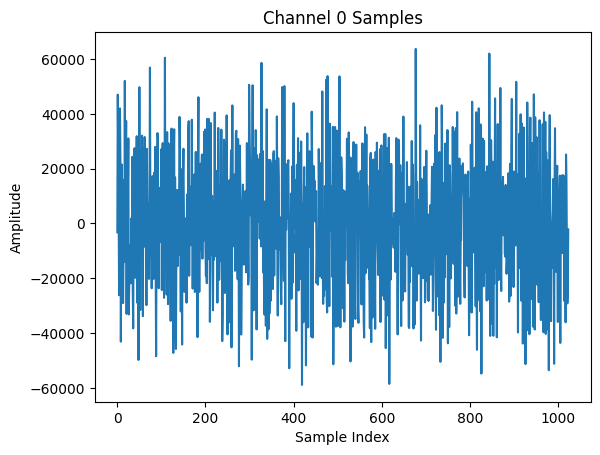

In [8]:
# path = "/Users/brunogas/manips/Tests-Modo/Avec_voie_analogique/WhiteNoise-2m.dat"
path = "/Users/brunogas/Manips/Tests-modo/Avec_voie_analogique/WhiteNoise-2m.dat"
# Read binary file as int32 elements
with open(path, "r") as f:
    data = np.fromfile(f, dtype=np.int32)

nbytes = data.shape[0]
nchannels = 256 + 1 + 1
nsamples = nbytes // nchannels
print("Bytes=", nbytes)
print("Channels=", nchannels)
print("Samples=", nsamples)

# Get 1024 samples starting from sample 0s
sample_start = 5000 * nchannels
sample_end = sample_start + 1024 * nchannels
selected_samples = data[sample_start:sample_end]

# reshape into an array of shape (nsamples, nchannels)
selected_samples_reshaped = selected_samples.reshape((-1, nchannels))
print("selected_samples_reshaped.shape: ", selected_samples_reshaped.shape)

# Plot the channel 0
plt.plot(selected_samples_reshaped[:, 257])
plt.title("Channel 0 Samples")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.show()